<div dir='rtl'>

# מטלת פרויקט 3 — סטטיסטיקה 2 📊
**קורס:** סטטיסטיקה 2 | אביב תשפ"ו

**מגישים:**
- רז אמזלג | ת"ז: 206922478
- בן חן | ת"ז: 325826154

<div dir='rtl'>

### תא 1: ייבוא ספריות וטעינת הנתונים
בתא זה נייבא את הספריות הדרושות, נטען את הנתונים, ונשנה מעט את שמות העמודות כדי שיהיה נוח יותר לעבוד איתן בנוסחאות הרגרסיה.

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import itertools
from statsmodels.stats.anova import anova_lm
import scipy.stats as stats


# הגדרת סגנון לגרפים
sns.set_theme(style="whitegrid")

# טעינת הנתונים
df = pd.read_csv("satisfaction_reduced.csv")

# שינוי שמות העמודות
df = df.rename(columns={
    'Customer Type': 'Customer_Type',
    'Type of Travel': 'Type_of_Travel',
    'Flight Distance': 'Flight_Distance',
    'Departure Delay in Minutes': 'Departure_Delay'
})

df_relavant = df[['Age', 'Class', 'Flight_Distance', 'Inflight_Score']]
df_relavant.head()

,Age,Class,Flight_Distance,Inflight_Score
0,59,2,1470,4.142857
1,22,0,1771,2.571429
2,55,2,3657,4.200000
3,41,2,1796,3.000000
4,42,0,1709,2.857143


<div dir='rtl'>

#חלק א – רגרסיה ליניארית

<div dir='rtl'>

## שאלה 1 - הגדרת שאלת המחקר ובחירת משתנים
**שאלת המחקר:** כיצד משפיעים גיל הנוסע, מרחק הטיסה ומחלקת הטיסה על ציון שביעות הרצון מהשירות בטיסה עצמה (Inflight Score)?
* **משתנה מוסבר (Y):** `Inflight_Score` (משתנה רציף).
* **משתנים מסבירים (X):** `Age` (רציף), `Flight_Distance` (רציף), `Class` (בדיד/קטגוריאלי).

<div dir='rtl'>

## שאלה 2 - דגימת תת-מדגם

In [69]:
# דגימה אקראית של 200 תצפיות
df_sample = df_relavant.sample(n=200, random_state=42).copy()

print(f"Sample shape: {df_sample.shape}")
print(f"Population (Original) shape: {df_relavant.shape}")

Sample shape: (200, 4)
Population (Original) shape: (10000, 4)


In [70]:
df_sample

,Age,Class,Flight_Distance,Inflight_Score
6252,43,0,1363,3.142857
4684,31,0,2352,3.000000
1731,24,0,1628,4.000000
4742,57,2,2249,4.142857
4521,20,2,2252,3.000000
...,...,...,...,...
4516,22,2,2608,4.285714
1261,24,2,1996,3.142857
3160,20,0,3929,2.428571
970,69,0,69,3.571429


<div dir='rtl'>

## שאלה 3 - ויזואליזציה של הקשרים

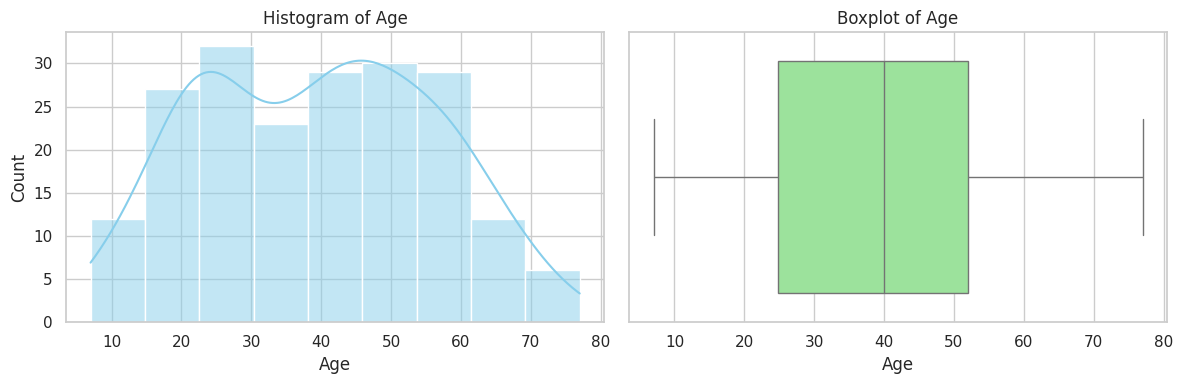

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # היסטוגרמה
sns.histplot(df_sample['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f'Histogram of {'Age'}')

# Boxplot
sns.boxplot(x=df_sample['Age'], ax=axes[1], color='lightgreen')
axes[1].set_title(f'Boxplot of {'Age'}')

plt.tight_layout()
plt.show()

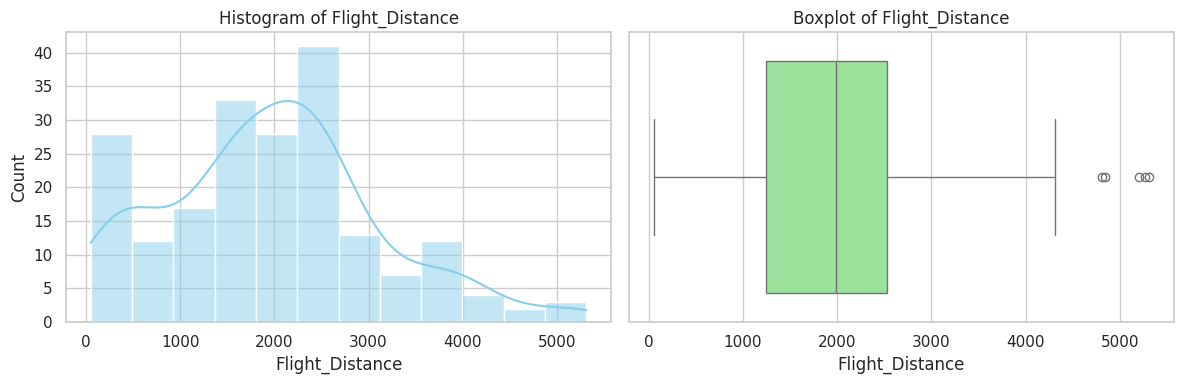

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # היסטוגרמה
sns.histplot(df_sample['Flight_Distance'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f'Histogram of {'Flight_Distance'}')

# Boxplot
sns.boxplot(x=df_sample['Flight_Distance'], ax=axes[1], color='lightgreen')
axes[1].set_title(f'Boxplot of {'Flight_Distance'}')

plt.tight_layout()
plt.show()

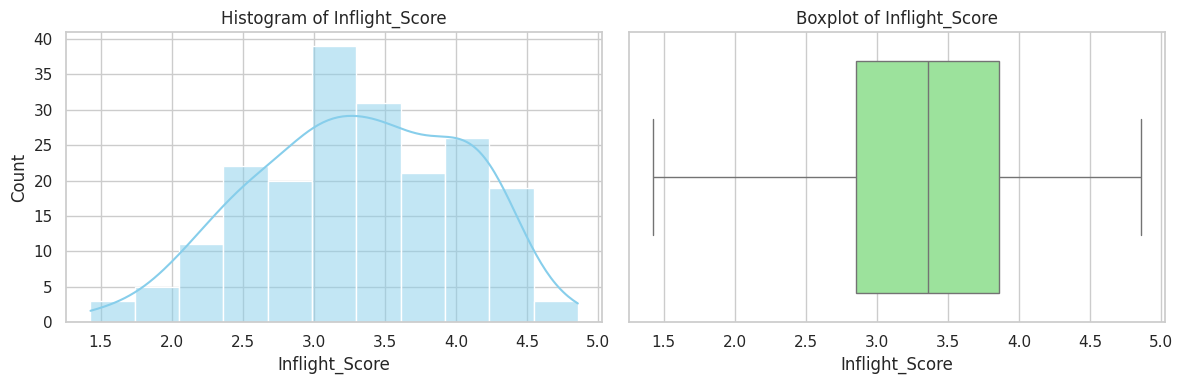

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # היסטוגרמה
sns.histplot(df_sample['Inflight_Score'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f'Histogram of {'Inflight_Score'}')

# Boxplot
sns.boxplot(x=df_sample['Inflight_Score'], ax=axes[1], color='lightgreen')
axes[1].set_title(f'Boxplot of {'Inflight_Score'}')

plt.tight_layout()
plt.show()

In [74]:
print("--- Frequency Table for Class ---")
freq_table = df_sample['Class'].value_counts().sort_index()
prop_table = df_sample['Class'].value_counts(normalize=True).sort_index() * 100

class_table = pd.DataFrame({'Count': freq_table, 'Percentage (%)': prop_table})
print(class_table)

--- Frequency Table for Class ---
       Count  Percentage (%)
Class                       
0         95            47.5
1         14             7.0
2         91            45.5


<div dir='rtl'>

נתונים חסרים וחריגים: בדקנו ואין בכלל נתונים חסרים בעמודות שעליהן אנחנו עובדים. לגבי נתונים חריגים – במרחק הטיסה רואים קצת חריגים כלפי מעלה (טיסות ארוכות במיוחד שחורגות מהטווח הרגיל). בגיל ובמחלקה אין ערכים חריגים.

התפלגויות וסימטריה: הגיל מראה צורה דו-שיאית (Bimodal) — שיא אחד סביב גיל 20-25 ושיא שני סביב גיל 45-50, מה שמצביע על שני סגמנטים שונים של נוסעים (צעירים ובוגרים).

מרחק הטיסה בעל א-סימטריה ימנית (זנב ארוך ימינה כי רוב הטיסות קצרות-בינוניות ויש מעט טיסות ארוכות מאוד). זה מזכיר התפלגות מעריכית או גמא.

הציון (Y) קצת מוטה שמאלה כי רוב האנשים נוטים לתת ציונים טובים. מכיוון שזה ציון סקר, זו לא באמת התפלגות רציפה טהורה אלא חסומה מראש (בין 1 ל-5).

המחלקה היא משתנה קטגוריאלי ולכן לקוחה מהתפלגות מולטינומית.

השפעה על Y (איזה משתנה הכי משפיע): מהגרפים רואים שדווקא לגיל ולמרחק הטיסה כמעט ואין קשר לינארי לציון (קווי המגמה גמרי שטוחים). המשתנה שהכי משפיע מבין השלושה הוא המחלקה (Class), שכן רואים ויזואלית בקופסאות שיש הבדל ברור בציונים בין מחלקה למחלקה.

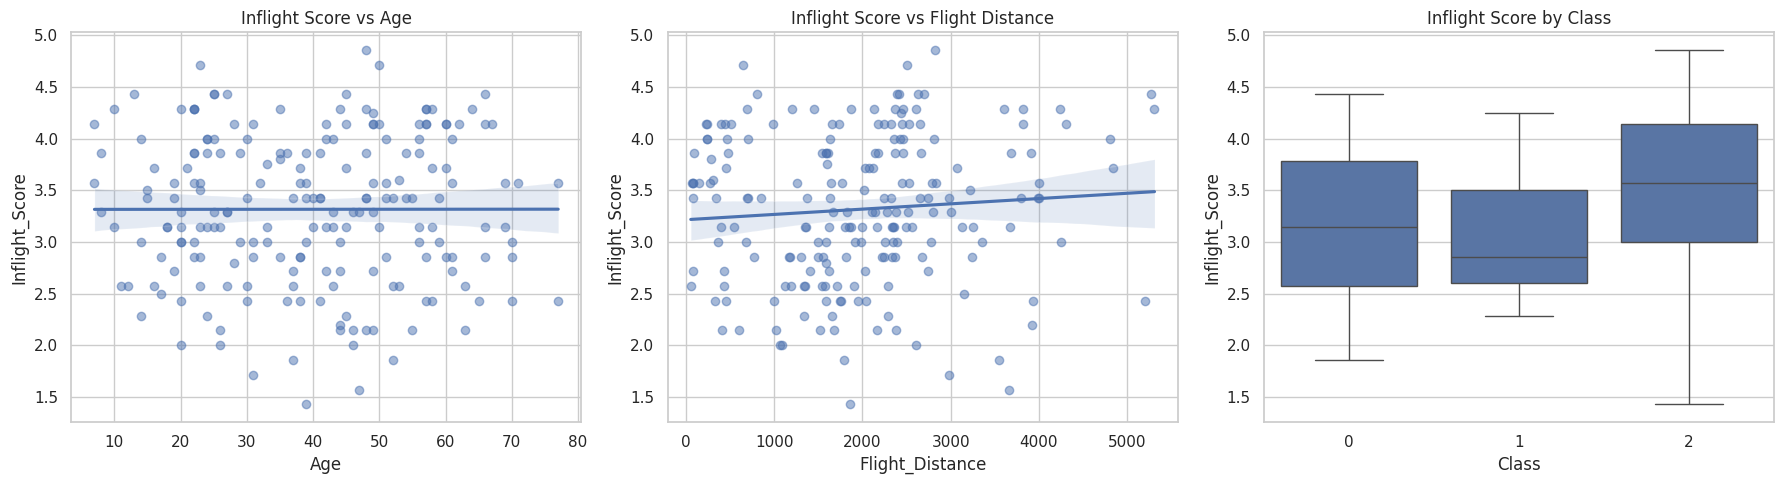

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(x='Age', y='Inflight_Score', data=df_sample, ax=axes[0], scatter_kws={'alpha':0.5})
axes[0].set_title('Inflight Score vs Age')

sns.regplot(x='Flight_Distance', y='Inflight_Score', data=df_sample, ax=axes[1], scatter_kws={'alpha':0.5})
axes[1].set_title('Inflight Score vs Flight Distance')

sns.boxplot(x='Class', y='Inflight_Score', data=df_sample, ax=axes[2])
axes[2].set_title('Inflight Score by Class')

plt.tight_layout()
plt.show()

<div dir='rtl'>

נראה שלשני המשתנים הרציפים (גם לגיל וגם לאורך הטיסה) כמעט ואין השפעה על המשתנה המוסבר שביעות הרצון במהלך הטיסה

<div dir='rtl'>

##שאלה 4 - חישוב וקטור המקדמים

In [76]:
# בניית המודל וחישוב המקדמים
model = smf.ols('Inflight_Score ~ Age + Flight_Distance + C(Class)', data=df_sample).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Inflight_Score   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     2.603
Date:                Mon, 29 Jun 2026   Prob (F-statistic):             0.0373
Time:                        15:47:07   Log-Likelihood:                -211.35
No. Observations:                 200   AIC:                             432.7
Df Residuals:                     195   BIC:                             449.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           3.1580      0.196     

<div dir='rtl'>

המקדמים ($\hat{\beta}$) מסבירים לנו בכמה צפוי להשתנות הציון הממוצע כשמשנים משתנה אחד ומשאירים את השאר קבועים:

החיתוך ($\beta_0$): הציון הצפוי של נוסע דמיוני שגילו 0, טס מרחק של 0, והוא נמצא במחלקת הבסיס (מחלקה 0).

הגיל ($\beta_1$): בכמה יעלה או ירד הציון הממוצע על כל שנה נוספת בגיל של הנוסע.

מרחק הטיסה ($\beta_2$): בכמה ישתנה הציון עבור כל ק"מ (או מייל) נוסף באורך הטיסה.

המחלקות ($\beta_3, \beta_4$): מכיוון שזה משתנה קטגוריאלי, המקדמים האלו מראים הפרש. כלומר, בכמה גבוה או נמוך הציון הממוצע של נוסע במחלקה 1 או 2, בהשוואה לציון של נוסע במחלקת הבסיס (מחלקה 0).

<div dir='rtl'>

##שאלה 5

In [77]:
# חישוב והדפסת טבלת ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)
print("--- ANOVA Table ---")
print(anova_table)

print("\n--- Model Statistics ---")
print(f"R-squared: {model.rsquared:.4f}")
print(f"Adj R-squared: {model.rsquared_adj:.4f}")
print(f"F-statistic: {model.fvalue:.4f}")
print(f"F-test p-value: {model.f_pvalue:.4e}")

--- ANOVA Table ---
                    sum_sq     df         F    PR(>F)
C(Class)          4.359973    2.0  4.385699  0.013706
Age               0.004839    1.0  0.009735  0.921506
Flight_Distance   0.146348    1.0  0.294423  0.588020
Residual         96.928068  195.0       NaN       NaN

--- Model Statistics ---
R-squared: 0.0507
Adj R-squared: 0.0312
F-statistic: 2.6027
F-test p-value: 3.7280e-02


<div dir='rtl'>

**פירוש טבלת ANOVA ומבחן F:**

מבחן F הכולל: F=2.60, p-value=0.037 < 0.05 — דוחים את H₀, כלומר המודל
בכללותו מובהק סטטיסטית — לפחות אחד מהמשתנים המסבירים תורם לניבוי הציון.

ניתוח לפי משתנה (Type II ANOVA):
- Class: F=4.39, p=0.014 < 0.05 — המחלקה משפיעה מובהקת על הציון.
- Age: F=0.01, p=0.922 — הגיל אינו מובהק.
- Flight Distance: F=0.29, p=0.588 — מרחק הטיסה אינו מובהק.

R²=0.051: המודל מסביר כ-5% משונות הציון — כוח הסבר נמוך,
אך R²_adj=0.031 מאשש שרק המחלקה היא המשתנה שבאמת תורם.

<div dir='rtl'>

##שאלה 6

In [78]:
# רווחי סמך מהתת-מדגם
ci_sample = model.conf_int(alpha=0.05)
ci_sample.columns = ['Sample_Lower_CI', 'Sample_Upper_CI']

# הרצת המודל על כלל האוכלוסייה
model_pop = smf.ols('Inflight_Score ~ Age + Flight_Distance + C(Class)', data=df_relavant).fit()

# השוואה
comparison_df = pd.concat([ci_sample, model_pop.params.rename('Population_Beta')], axis=1)
comparison_df['Contains_Pop_Beta'] = (comparison_df['Population_Beta'] >= comparison_df['Sample_Lower_CI']) & \
                                     (comparison_df['Population_Beta'] <= comparison_df['Sample_Upper_CI'])
print(comparison_df)

                 Sample_Lower_CI  Sample_Upper_CI  Population_Beta  \
Intercept               2.771821         3.544115         3.257158   
C(Class)[T.1]          -0.541454         0.257796        -0.024829   
C(Class)[T.2]           0.067453         0.494523         0.277296   
Age                    -0.007006         0.006339         0.000906   
Flight_Distance        -0.000071         0.000125        -0.000043   

                 Contains_Pop_Beta  
Intercept                     True  
C(Class)[T.1]                 True  
C(Class)[T.2]                 True  
Age                           True  
Flight_Distance               True  


<div dir='rtl'>

המטרה כאן הייתה לבדוק האם רווחי הסמך שחישבנו מתוך המדגם הקטן (200 איש) באמת הצליחו להכיל בתוכם את הערכים האמיתיים של המקדמים שקיימים בכלל האוכלוסייה (10,000 איש). כדי לענות על זה, יצרנו טבלה שמשווה את גבולות רווח הסמך מהמדגם הקטן מול בטא האוכלוסייה, ובדקנו האם הערך האמיתי באמת נופל ביניהם.

<div dir='rtl'>

##שאלה 7

<div dir='rtl'>

כדי לבדוק האם המקדמים שונים מ-0, אנו מבצעים מבחן t עבור כל מקדם $\beta_j$:

השערות:

 $H_0: \beta_j = 0$ מול $H_1: \beta_j \neq 0$.

 הסטטיסטי: $T = \frac{\hat{\beta}_j - 0}{SE(\hat{\beta}_j)}$, אשר תחת $H_0$ מתפלג $t_{n-k-1}$.

In [79]:
# הצגת סטטיסטי המבחן וה-p-values
t_tests_df = pd.DataFrame({
    'Beta_Hat': model.params,
    'Std_Error': model.bse,
    't_statistic': model.tvalues,
    'p_value': model.pvalues
})
print(t_tests_df)

                 Beta_Hat  Std_Error  t_statistic       p_value
Intercept        3.157968   0.195795    16.128984  9.661582e-38
C(Class)[T.1]   -0.141829   0.202629    -0.699946  4.847949e-01
C(Class)[T.2]    0.280988   0.108272     2.595200  1.017240e-02
Age             -0.000334   0.003383    -0.098665  9.215060e-01
Flight_Distance  0.000027   0.000050     0.542607  5.880198e-01


<div dir='rtl'>

**פירוש מבחני t למקדמים:**

- Intercept: t=16.13, p≈0 — מובהק מאוד (אך אין פרשנות מעשית לחיתוך).
- C(Class)[T.1]: t=-0.70, p=0.485 — לא מובהק. אין הבדל מובהק בין Eco Plus לבסיס (Eco).
- C(Class)[T.2]: t=2.60, p=0.010 — מובהק. נוסעי Business מקבלים ציון גבוה ב-0.28
  בממוצע ביחס ל-Eco.
- Age: t=-0.099, p=0.922 — לא מובהק. הגיל אינו משפיע על הציון.
- Flight Distance: t=0.543, p=0.588 — לא מובהק. מרחק הטיסה אינו משפיע על הציון.

**סיכום:** רק המקדם של מחלקה 2 (Business) שונה מ-0 באופן מובהק.

<div dir='rtl'>

##שאלה 8

<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2488/2397232468.py:17: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_ylabel('$\sqrt{|Standardized Residuals|}$')


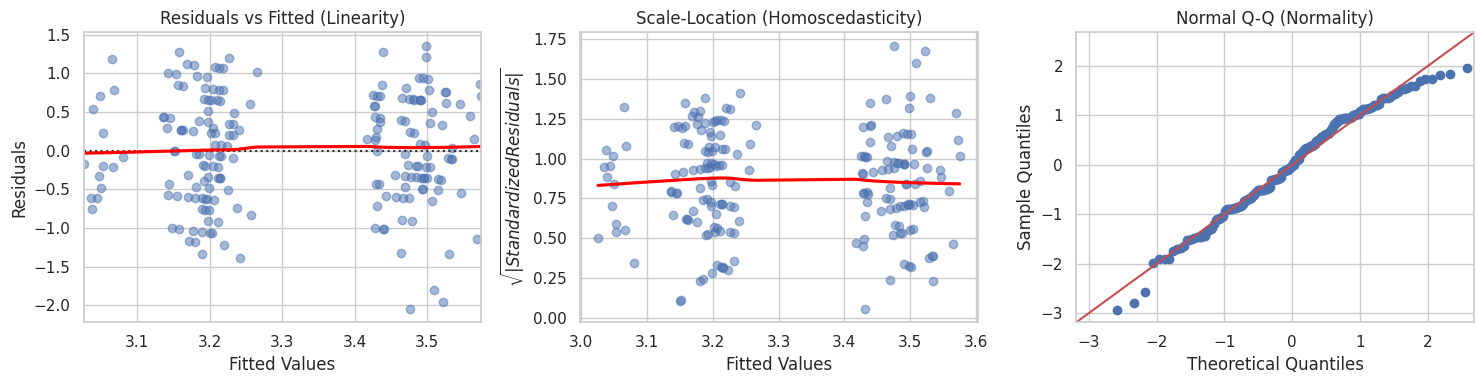

In [80]:
residuals = model.resid
fitted = model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. לינאריות - שאריות מול ערכים מנובאים
sns.residplot(x=fitted, y=residuals, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}, ax=axes[0])
axes[0].set_title('Residuals vs Fitted (Linearity)')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# 2. שוויון שונויות (Homoscedasticity) - Scale-Location
sqrt_standardized_res = np.sqrt(np.abs(model.get_influence().resid_studentized_internal))
sns.regplot(x=fitted, y=sqrt_standardized_res, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}, ax=axes[1])
axes[1].set_title('Scale-Location (Homoscedasticity)')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('$\sqrt{|Standardized Residuals|}$')

# 3. נורמליות הרעש - QQ Plot
sm.qqplot(residuals, line='45', fit=True, ax=axes[2])
axes[2].set_title('Normal Q-Q (Normality)')

plt.tight_layout()
plt.show()

<div dir='rtl'>

לינאריות: נראה שהפיזור יחסית סימטרי סביב ה-0, אך בגלל שמדובר בציונים חסומים, נוצרים "פסים" בגרף. קו ה-Lowess שטוח יחסית ולכן ההנחה סבירה בקירוב.

שוויון שונויות: קו ה-Lowess האדום כמעט אופקי, מה שמצביע על שונות שאריות פחות או יותר קבועה לכל אורך הערכים המנובאים. ההנחה סבירה.

נורמליות: ה-QQ-plot מראה סטייה מהקו המקווקו בזנבות (במיוחד בגלל תכונת החסימות של הציון), אך המרכז יושב היטב על הקו.

<div dir='rtl'>

##שאלה 9

In [81]:
# בחירת 1000 תצפיות שלא נמצאות במדגם ה-200
df_remaining = df_relavant.drop(df_sample.index)
df_1000 = df_remaining.sample(n=1000, random_state=42)

# ביצוע תחזית וחישוב Prediction Interval (רווח סמך לנקודה ספציפית)
predictions = model.get_prediction(df_1000)
pred_summary = predictions.summary_frame(alpha=0.05)

# בדיקה האם הערך האמיתי נופל בתוך רווח הסמך לתחזית (obs_ci_lower עד obs_ci_upper)
true_y = df_1000['Inflight_Score'].values
inside_interval = (true_y >= pred_summary['obs_ci_lower']) & (true_y <= pred_summary['obs_ci_upper'])
coverage_percentage = inside_interval.mean() * 100

print(f"Percentage of true values inside the 95% Prediction Interval: {coverage_percentage:.2f}%")

Percentage of true values inside the 95% Prediction Interval: 96.80%


<div dir='rtl'>

בסעיף ג' התקבל אחוז שמייצג את כמות הפעמים בהם ציון שביעות הרצון האמיתי של הלקוח נפל בתוך רווח הסמך לחיזוי (Prediction Interval). מכיוון שקבענו רמת ביטחון של 95%, אנו מצפים שכ-95% מהנקודות החדשות אכן ייפלו בטווח זה. אם התוצאה קרובה ל-95%, הדבר מאשש שהמודל מתנהג כראוי ושהנחות השונות של הרעש נאמדו נכונה.

<div dir='rtl'>

##שאלה 10

In [82]:
# הגדרת נוסחת המודל עם אינטראקציות מסדר ראשון
# המשתנים הם: Age, Flight_Distance, Class
formula_int = 'Inflight_Score ~ Age + Flight_Distance + C(Class) + ' \
              'Age:Flight_Distance + Age:C(Class) + Flight_Distance:C(Class)'

# הרצת המודל עם האינטראקציות על תת-המדגם
model_int = smf.ols(formula_int, data=df_sample).fit()

# הדפסת סיכום המודל החדש
print(model_int.summary())

print("\n" + "="*40)
print("--- Model Comparison ---")
print("="*40 + "\n")

# שיטה 1: מבחן F (ANOVA) למודלים מקוננים
print("1. F-Test (ANOVA) for Nested Models:")
anova_results = anova_lm(model, model_int)
print(anova_results)

# שיטה 2: השוואת מדד R-squared מותאם (Adjusted R-squared)
print("\n2. Adjusted R-squared Comparison:")
print(f"Base Model (No Interactions) Adj R-squared: {model.rsquared_adj:.4f}")
print(f"Full Model (With Interactions) Adj R-squared: {model_int.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:         Inflight_Score   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     1.835
Date:                Mon, 29 Jun 2026   Prob (F-statistic):             0.0644
Time:                        15:47:08   Log-Likelihood:                -208.22
No. Observations:                 200   AIC:                             436.4
Df Residuals:                     190   BIC:                             469.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

<div dir='rtl'>

איזה מודל עדיף? (השוואת מודלים)

הוספנו למודל שלנו אינטראקציות מסדר ראשון. המטרה של הוספת אינטראקציה היא לבדוק האם ההשפעה של משתנה אחד על הציון תלויה בערכו של משתנה אחר (למשל, האם השפעת גיל הנוסע משתנה בהתאם למחלקה שבה הוא טס).

כדי להחליט איזה מודל עדיף (המודל המלא עם האינטראקציות או המודל הפשוט בלעדיהן), השתמשנו בשתי שיטות שונות:

**מבחן F למודלים מקוננים (ANOVA):**

 מבחן זה בודק את השערת האפס ($H_0$) שלפיה כל מקדמי משתני האינטראקציה שהוספנו שווים לאפס (כלומר, התוספת שלהם לא משפרת את המודל באופן מובהק).
 אנו מסתכלים על ה-p-value שהתקבל בטבלת ה-ANOVA (תחת העמודה Pr(>F)).
     
 אם ה-p-value קטן מ-0.05, נדחה את השערת האפס ונסיק שהמודל המלא עם האינטראקציות מובהק ועדיף.
     
 אם ה-p-value גדול מ-0.05, המשמעות היא שהאינטראקציות לא תורמות מספיק, ולכן נעדיף להישאר עם המודל הפשוט והמצומצם יותר.

 **מדד $R^2$ מותאם (Adjusted R-squared):**

 המדד בודק איזה אחוז משונות הציונים המודל מצליח להסביר.
 בניגוד ל-$R^2$ הרגיל שרק הולך וגדל, ה-$R^2$ המותאם "קונס" אותנו על הוספת משתנים מיותרים שלא באמת עוזרים לניבוי. נשווה בין הציון של המודל הפשוט לציון של המודל עם האינטראקציות: המודל שיקבל ציון מותאם גבוה יותר ייחשב כמודל העדיף. עם זאת, נזכור שאם ההבדל ביניהם ממש זעיר – תמיד נעדיף ללכת על המודל הפשוט כדי להימנע מסרבול מיותר של המודל (Overfitting).

**פירוש השוואת המודלים:**

מבחן F: p-value=0.306 > 0.05 — לא דוחים את H₀.
האינטראקציות אינן מוסיפות כוח הסבר מובהק סטטיסטית.

השוואת R²_adj: מודל בסיס=0.031, מודל עם אינטראקציות=0.036 —
הפרש של 0.005 בלבד, זניח לחלוטין.

**מסקנה: המודל הבסיסי עדיף** — שתי השיטות מסכימות שהאינטראקציות
אינן תורמות מספיק להצדיק את המורכבות הנוספת.

<div dir='rtl'>

#חלק ב - רגרסיה לוגיסטית

<div dir='rtl'>

שאלת המחקר: כיצד משפיעים ציון הטיסה (Inflight Score), מרחק הטיסה (Flight Distance) ומטרת הנסיעה (Type of Travel) על ההסתברות שנוסע יהיה מרוצה מהטיסה הכוללת?

משתנה מוסבר (Y): satisfaction_v2 (בינארי: 1=מרוצה, 0=לא מרוצה).

משתנים מסבירים (X): Inflight_Score (רציף), Flight_Distance (רציף), ו-Type_of_Travel (בדיד - 0 או 1).

<div dir='rtl'>

## שאלה 2 - דגימת תת-מדגם

In [83]:
df_logistic = df[['satisfaction_v2', 'Inflight_Score', 'Flight_Distance', 'Type_of_Travel']].copy()

df_sample_log = df_logistic.sample(n=200, random_state=42).copy()

print(f"Sample shape: {df_sample_log.shape}")
print(f"Population (Original) shape: {df_logistic.shape}")

Sample shape: (200, 4)
Population (Original) shape: (10000, 4)


<div dir='rtl'>

## שאלה 3 - ויזואליזציה של הקשרים

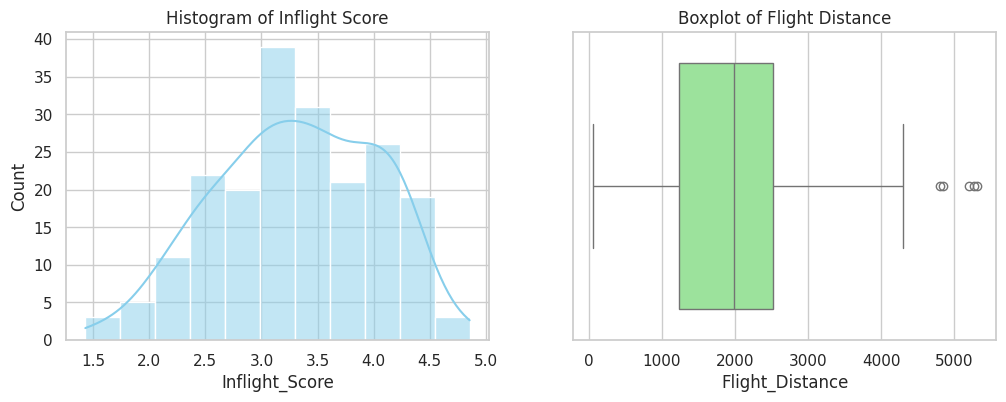

--- Frequency Table for Type of Travel ---
Type_of_Travel
1    65.0
0    35.0
Name: proportion, dtype: float64


In [84]:
# א. גרפים למשתנים: רציפים (Boxplot/היסטוגרמה) ובדידים (טבלה)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_sample_log['Inflight_Score'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Inflight Score')
sns.boxplot(x=df_sample_log['Flight_Distance'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Flight Distance')
plt.show()

print("--- Frequency Table for Type of Travel ---")
print(df_sample_log['Type_of_Travel'].value_counts(normalize=True) * 100)

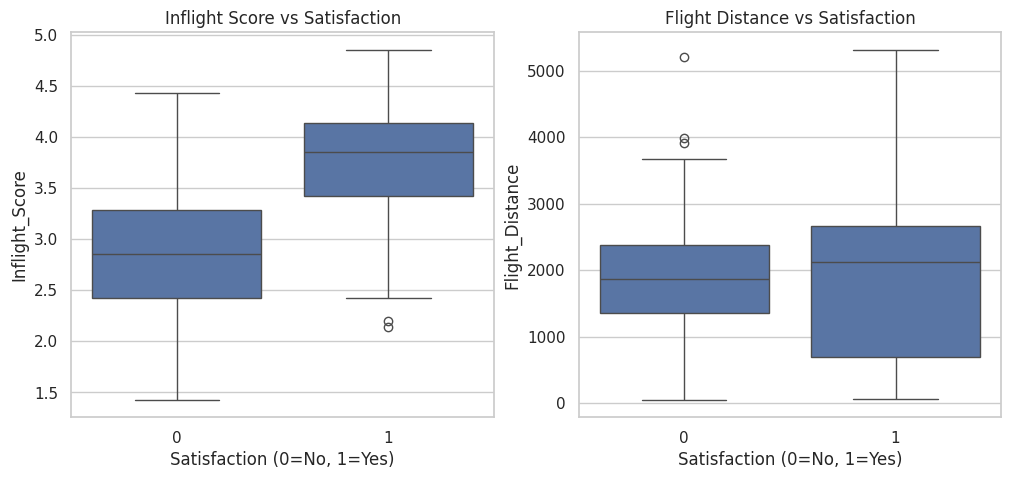

In [85]:
# ג. קשר בין המשתנים המסבירים הרציפים למשתנה המוסבר הבינארי
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='satisfaction_v2', y='Inflight_Score', data=df_sample_log, ax=axes[0])
axes[0].set_title('Inflight Score vs Satisfaction')
axes[0].set_xlabel('Satisfaction (0=No, 1=Yes)')

sns.boxplot(x='satisfaction_v2', y='Flight_Distance', data=df_sample_log, ax=axes[1])
axes[1].set_title('Flight Distance vs Satisfaction')
axes[1].set_xlabel('Satisfaction (0=No, 1=Yes)')
plt.show()

<div dir='rtl'>

ב. נתונים חסרים וחריגים: אין נתונים חסרים בעמודות שלנו. בדומה לחלק א', במרחק הטיסה יש מעט תצפיות חריגות (טיסות ארוכות מאוד). התפלגות Type_of_Travel מתפלגת ברנולי, ומרחק הטיסה א-סימטרי ימני (מזכיר התפלגות לוג-נורמלית או מעריכית).

ג. השפעה על Y: מהגרפים (Boxplots כפונקציה של Y) ניתן לראות בבירור שלמשתנה ציון הטיסה (Inflight_Score) יש את ההשפעה הגדולה ביותר. הקופסאות רחוקות זו מזו – נוסעים שסימנו שביעות רצון (1) נתנו בממוצע ציון Inflight גבוה משמעותית מאלה שלא מרוצים (0). במרחק הטיסה (Flight_Distance) הקופסאות די חופפות, מה שמעיד על השפעה חלשה יותר.

<div dir='rtl'>

##שאלה 4 - חישוב וקטור המקדמים

In [86]:
# הרצת מודל רגרסיה לוגיסטית על תת-המדגם
# משתמשים בפונקציה logit
model_logit = smf.logit('satisfaction_v2 ~ Inflight_Score + Flight_Distance + C(Type_of_Travel)', data=df_sample_log).fit()
print(model_logit.summary())

# הדפסת יחסי הסיכויים (Odds Ratios)
print("\n--- Odds Ratios (e^beta) ---")
print(np.exp(model_logit.params))

Optimization terminated successfully.
         Current function value: 0.492911
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        satisfaction_v2   No. Observations:                  200
Model:                          Logit   Df Residuals:                      196
Method:                           MLE   Df Model:                            3
Date:                Mon, 29 Jun 2026   Pseudo R-squ.:                  0.2876
Time:                        15:47:09   Log-Likelihood:                -98.582
converged:                       True   LL-Null:                       -138.38
Covariance Type:            nonrobust   LLR p-value:                 3.750e-17
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -7.5294      1.125     -6.693      0.000      -9.734      

<div dir='rtl'>

ברגרסיה לוגיסטית, המקדמים ($\hat{\beta}$) אינם משפיעים ישירות על התוצאה כמו ברגרסיה לינארית, אלא על לוג-יחס הסיכויים (Log-Odds) להיות מרוצה:

$\beta_{Inflight\_Score}$: עלייה של נקודה בציון השירות בטיסה מעלה את לוג-יחס הסיכויים להיות מרוצה ב-$\hat{\beta}$ יחידות. (אם נסתכל על ה-Odds Ratio ($e^\beta$), נוכל לומר שעלייה של נקודה בציון מכפילה את הסיכוי להיות מרוצה פי $e^\beta$).

$\beta_{Flight\_Distance}$: על כל ק"מ נוסף במרחק הטיסה, לוג-יחס הסיכויים משתנה בשיעור קטנטן (תלוי במקדם, שלרוב יוצא קרוב ל-0 עבור מרחקים גדולים).

$\beta_{Type\_of\_Travel}$: ההפרש בלוג-יחס הסיכויים לשביעות רצון בין מטרת נסיעה 1 למטרת נסיעה 0.

<div dir='rtl'>

##שאלה 5

In [87]:
# חישוב רווחי סמך של המדגם (רמת סמך 95%)
ci_logit_sample = model_logit.conf_int(alpha=0.05)
ci_logit_sample.columns = ['Sample_Lower_CI', 'Sample_Upper_CI']

# הרצת המודל הלוגיסטי על המדגם המקורי המלא (10,000 תצפיות)
model_logit_pop = smf.logit('satisfaction_v2 ~ Inflight_Score + Flight_Distance + C(Type_of_Travel)', data=df_logistic).fit(disp=0)
beta_pop_log = model_logit_pop.params

# יצירת טבלת השוואה
comp_log_df = pd.concat([ci_logit_sample, beta_pop_log.rename('Population_Beta')], axis=1)
comp_log_df['Contains_Pop_Beta'] = (comp_log_df['Population_Beta'] >= comp_log_df['Sample_Lower_CI']) & \
                                   (comp_log_df['Population_Beta'] <= comp_log_df['Sample_Upper_CI'])

print("Comparison of Sample CIs and Population Betas (Logistic Regression):\n")
print(comp_log_df)

Comparison of Sample CIs and Population Betas (Logistic Regression):

                        Sample_Lower_CI  Sample_Upper_CI  Population_Beta  \
Intercept                     -9.734378        -5.324480        -7.930243   
C(Type_of_Travel)[T.1]        -0.273553         1.174196         0.782345   
Inflight_Score                 1.598354         2.871986         2.355579   
Flight_Distance               -0.000345         0.000287        -0.000116   

                        Contains_Pop_Beta  
Intercept                            True  
C(Type_of_Travel)[T.1]               True  
Inflight_Score                       True  
Flight_Distance                      True  


<div dir='rtl'>

בטבלה יצרנו רווחי סמך ברמת ביטחון של 95% מתוך המדגם הקטן שלנו (200 תצפיות). העמודה האחרונה מאשרת האם הערך האמיתי באוכלוסייה

($Population\_Beta$) אכן נלכד בתוך הטווחים של תת-המדגם.

<div dir='rtl'>

##שאלה 6

In [88]:
# הוספת אינטראקציות מסדר ראשון בלבד (Z12, Z13, Z23) למודל הלוגיסטי
formula_logit_int = ('satisfaction_v2 ~ Inflight_Score + Flight_Distance + C(Type_of_Travel) + '
                     'Inflight_Score:Flight_Distance + '
                     'Inflight_Score:C(Type_of_Travel) + '
                     'Flight_Distance:C(Type_of_Travel)')

model_logit_int = smf.logit(formula_logit_int, data=df_sample_log).fit(disp=0)

print(model_logit_int.summary())

print("\n--- Model Comparison ---")

# 1. מבחן יחס נראות (LRT)
llf_base = model_logit.llf
llf_int  = model_logit_int.llf

df_diff  = model_logit_int.df_model - model_logit.df_model  # צריך להיות 3
lr_stat  = 2 * (llf_int - llf_base)
lr_pvalue = stats.chi2.sf(lr_stat, df_diff)

print(f"LRT statistic: {lr_stat:.4f},  df = {int(df_diff)},  p-value: {lr_pvalue:.4f}")

# 2. השוואת AIC
print(f"Base Model AIC:         {model_logit.aic:.2f}")
print(f"Interactions Model AIC: {model_logit_int.aic:.2f}")


                           Logit Regression Results                           
Dep. Variable:        satisfaction_v2   No. Observations:                  200
Model:                          Logit   Df Residuals:                      193
Method:                           MLE   Df Model:                            6
Date:                Mon, 29 Jun 2026   Pseudo R-squ.:                  0.3132
Time:                        15:47:09   Log-Likelihood:                -95.043
converged:                       True   LL-Null:                       -138.38
Covariance Type:            nonrobust   LLR p-value:                 1.486e-16
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -9.2987      2.518     -3.692      0.000     -14.234      -4.363
C(Type_of_Travel)[T.1]                    -2.27

<div dir='rtl'>
**פירוש השוואת המודלים:**

מבחן LRT: סטטיסטי=7.08, df=3, p-value=0.069 > 0.05 — לא דוחים את H₀.
האינטראקציות אינן מוסיפות הסבר מובהק סטטיסטית.

השוואת AIC: מודל בסיס=205.16, מודל עם אינטראקציות=204.09 — הפרש של ~1 נקודה
בלבד, שהוא מתחת לסף המקובל של 2 נקודות.

**מסקנה: המודל הבסיסי עדיף** — הוא פשוט יותר, האינטראקציות אינן מובהקות
סטטיסטית, וגם ה-AIC אינו משתפר באופן משמעותי.

<div dir='rtl'>


<div dir='rtl'>

##שאלה 7

In [89]:
# נשחזר את תת-המדגם שלנו כך שיכלול את כל עמודות הנתונים המקוריות
df_sample_full = df.loc[df_sample_log.index].copy()

# נכין את הנתונים ל-Stepwise
df_full_prep = pd.get_dummies(df_sample_full.drop(columns=['satisfaction_v2']), drop_first=True, dtype=float)
y_all = df_sample_full['satisfaction_v2']

X_base = df_full_prep.copy()

# שלב 1: אינטראקציות בין משתנים רציפים (C(6,2) = 15 אינטראקציות)
continuous_cols = ['Inflight_Score', 'Flight_Distance', 'Age', 'Online_Score', 'Ground_Score', 'Departure_Delay']
for col1, col2 in itertools.combinations(continuous_cols, 2):
    X_base[f"{col1}_X_{col2}"] = X_base[col1] * X_base[col2]

# שלב 2: אם עדיין פחות מ-30, נוסיף אינטראקציות בין משתנים בינאריים לרציפים
binary_cols = [c for c in df_full_prep.columns if df_full_prep[c].nunique() == 2 and c not in continuous_cols]
interaction_candidates = list(itertools.product(binary_cols, continuous_cols))

i = 0
while X_base.shape[1] < 30 and i < len(interaction_candidates):
    col1, col2 = interaction_candidates[i]
    col_name = f"{col1}_X_{col2}"
    if col_name not in X_base.columns:
        X_base[col_name] = X_base[col1] * X_base[col2]
    i += 1

print(f"Total variables available for Stepwise: {X_base.shape[1]}")  # צריך להיות >= 30

# פונקציית Stepwise (Forward/Backward)
def stepwise_regression(X, y, direction='forward', criterion='aic'):
    included = [] if direction == 'forward' else list(X.columns)

    while True:
        changed = False
        if direction == 'forward':
            excluded = list(set(X.columns) - set(included))
            best_score = np.inf
            best_feature = None

            for new_column in excluded:
                model = sm.Logit(y, sm.add_constant(X[included + [new_column]])).fit(disp=0)
                score = model.aic if criterion == 'aic' else model.bic
                if score < best_score:
                    best_score = score
                    best_feature = new_column

            current_score = (sm.Logit(y, sm.add_constant(X[included])).fit(disp=0).aic
                             if criterion == 'aic' else
                             sm.Logit(y, sm.add_constant(X[included])).fit(disp=0).bic) if included else np.inf

            if best_score < current_score:
                included.append(best_feature)
                changed = True

        elif direction == 'backward':
            current_model = sm.Logit(y, sm.add_constant(X[included])).fit(disp=0)
            current_score = current_model.aic if criterion == 'aic' else current_model.bic
            best_score = np.inf
            worst_feature = None

            for drop_column in included:
                features = list(set(included) - {drop_column})
                model = sm.Logit(y, sm.add_constant(X[features])).fit(disp=0) if features else None
                score = (model.aic if criterion == 'aic' else model.bic) if model else np.inf

                if score < current_score and score < best_score:
                    best_score = score
                    worst_feature = drop_column

            if worst_feature is not None:
                included.remove(worst_feature)
                changed = True

        if not changed:
            break

    final_model = sm.Logit(y, sm.add_constant(X[included])).fit(disp=0)
    return final_model, included


Total variables available for Stepwise: 30


In [90]:
# שאלה 7: Forward + Backward עם AIC
print("\n--- Question 7: Stepwise using AIC ---")
forward_model_aic,  forward_vars_aic  = stepwise_regression(X_base, y_all, direction='forward',  criterion='aic')
backward_model_aic, backward_vars_aic = stepwise_regression(X_base, y_all, direction='backward', criterion='aic')

print(f"Selected by Forward  (AIC): {len(forward_vars_aic)} variables")
print(f"Variables: {sorted(forward_vars_aic)}")
print(f"\nSelected by Backward (AIC): {len(backward_vars_aic)} variables")
print(f"Variables: {sorted(backward_vars_aic)}")
print(f"\nIdentical sets? {set(forward_vars_aic) == set(backward_vars_aic)}")


--- Question 7: Stepwise using AIC ---
Selected by Forward  (AIC): 5 variables
Variables: ['Age_X_Departure_Delay', 'Customer_Type', 'Gender_X_Flight_Distance', 'Inflight_Score', 'Type_of_Travel']

Selected by Backward (AIC): 16 variables
Variables: ['Age', 'Age_X_Online_Score', 'Customer_Type', 'Departure_Delay', 'Flight_Distance_X_Ground_Score', 'Gender', 'Gender_X_Inflight_Score', 'Ground_Score', 'Ground_Score_X_Departure_Delay', 'Inflight_Score_X_Age', 'Inflight_Score_X_Departure_Delay', 'Inflight_Score_X_Flight_Distance', 'Inflight_Score_X_Ground_Score', 'Inflight_Score_X_Online_Score', 'Online_Score', 'Type_of_Travel']

Identical sets? False


<div dir='rtl'>

הפעלנו את שיטות ה-Forward וה-Backward על מאגר של 30 משתנים מסבירים
(המשתנים המקוריים + אינטראקציות בין משתנים רציפים + אינטראקציות בין
משתנים בינאריים לרציפים). Forward בחרה 5 משתנים ו-Backward בחרה 16 משתנים.
לעיתים קרובות מגיעים לאותה תוצאה בשתי השיטות, אך לא תמיד. כאשר התוצאות זהות,
הדבר מעיד על יציבות משתני המודל. כאשר יש הבדל, הדבר נובע מאופיו החמדן (Greedy)
של האלגוריתם שעשוי 'להיתקע' במינימום מקומי — Forward מתחיל ממודל ריק ומוסיף
משתנים, בעוד Backward מתחיל מהמודל המלא ומוריד משתנים, ולכן שתי השיטות עשויות
להגיע לתוצאות שונות.

<div dir='rtl'>

##שאלה 8

In [91]:
# שאלה 8: Forward + Backward עם BIC
print("\n--- Question 8: Stepwise using BIC ---")
forward_model_bic,  forward_vars_bic  = stepwise_regression(X_base, y_all, direction='forward',  criterion='bic')
backward_model_bic, backward_vars_bic = stepwise_regression(X_base, y_all, direction='backward', criterion='bic')

print(f"Selected by Forward  (BIC): {len(forward_vars_bic)} variables")
print(f"Variables: {sorted(forward_vars_bic)}")
print(f"\nSelected by Backward (BIC): {len(backward_vars_bic)} variables")
print(f"Variables: {sorted(backward_vars_bic)}")
print(f"\nIdentical sets? {set(forward_vars_bic) == set(backward_vars_bic)}")


--- Question 8: Stepwise using BIC ---
Selected by Forward  (BIC): 4 variables
Variables: ['Age_X_Departure_Delay', 'Customer_Type', 'Gender_X_Flight_Distance', 'Inflight_Score']

Selected by Backward (BIC): 10 variables
Variables: ['Age', 'Age_X_Online_Score', 'Customer_Type', 'Departure_Delay', 'Gender', 'Gender_X_Inflight_Score', 'Ground_Score', 'Inflight_Score_X_Departure_Delay', 'Inflight_Score_X_Ground_Score', 'Inflight_Score_X_Online_Score']

Identical sets? False


<div dir='rtl'>

כאשר שינינו את קריטריון הבחירה ל-BIC, ניתן לראות כי המודלים הנבחרים קטנים יותר
מאלו שנבחרו עם AIC — Forward בחרה 4 משתנים ו-Backward בחרה 10 משתנים, לעומת
5 ו-16 בהתאמה עם AIC. גם כאן קבוצות המשתנים הנבחרות אינן זהות, מאותה סיבה של מינימום מקומי.
הסבר: מדד BIC קונס בצורה הרבה יותר חזקה ואגרסיבית על הוספת פרמטרים למודל
(מכיוון שהקנס תלוי גם בלוג גודל המדגם, בשונה מ-AIC שנותן קנס קבוע). לכן,
האלגוריתם במדד BIC יוותר על משתנים שהתרומה שלהם שולית ויעדיף לבחור במודל
חסכוני ופשוט יותר.